# Step 1: Setup and data loading :-

In [68]:
# Importing necessary libraries for data manipulation, visualization, and modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings


### Setting professional - looking styles for plot :-

In [69]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,8)
warnings.filterwarnings('ignore')

# Step 2: Data import & initial exploration :-

In [ ]:
from src.data_loader import load_local_district_data
from src.cleaning import clean_text_columns, impute_median, drop_irrelevant_columns

try:
    df = load_local_district_data()
except FileNotFoundError as err:
    raise FileNotFoundError(
        "Could not find the local district dataset. Place `2015_16_Districtwise.csv` in the `data/` folder."
    ) from err

# Display high-level information
print("\n📋 Dataframe Info:")
print(df.info())

print("\n🪧 Sample lines:")
print(df.sample(5))

print("\n🔢 Statistics for each numerical column:")
print(df.describe())



📋 Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Columns: 819 entries, AC_YEAR to TOTCLS7G
dtypes: float64(13), int64(803), object(3)
memory usage: 4.2+ MB
None

🪧 Sample lines:
     AC_YEAR  STATCD  DISTCD      STATNAME    DISTNAME  DISTRICTS  BLOCKS  \
623  2015-16      32    3205        KERALA  MALAPPURAM          1      15   
373  2015-16      20    2009     JHARKHAND   SAHIBGANJ          1       9   
44   2015-16       3     311        PUNJAB    FIROZPUR          1       6   
423  2015-16      22    2205  CHHATTISGARH       KORBA          1       5   
619  2015-16      32    3201        KERALA   KASARAGOD          1       7   

     VILLAGES  CLUSTERS  TOTPOPULAT  ...  UUNI_ALL  UUNI_SC  UUNI_ST  \
623       128       136   4110956.0  ...     76764     8888     1190   
373      1282        74   1150038.0  ...      2121      177      987   
44        666        79   2026831.0  ...     24763    21234      313   
423       797       118   120

# Step 3: Data cleaning steps :-

In [71]:
# 2. DATA CLEANING AND PREPROCESSING
# ==============================================================================
print("\n\n🧹 Starting Data Cleaning and Preprocessing...")

# Rename columns to be more Python-friendly (e.g., removing spaces, converting to lowercase)
df.columns = df.columns.str.lower().str.replace(' ', '_')


# Handling Missing Values
# Identify columns with a significant number of missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print("\nMissing Values Percentage (%):")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# For this analysis, we'll impute missing values in key literacy and population columns
# using the median, which is robust to outliers.
imputer = SimpleImputer(strategy='median')
cols_to_impute = ['overall_li', 'female_lit', 'male_lit', 'p_sc_pop', 'p_st_pop']
df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])
print("\n✅ Missing values in key columns imputed using the median.")

# Drop columns that are less relevant for a general literacy analysis or are redundant
cols_to_drop = ['ac_year', 'distcd', 'statcd']
df_cleaned = df.drop(columns=cols_to_drop)
print(f"\n✅ Dropped irrelevant columns: {', '.join(cols_to_drop)}")




🧹 Starting Data Cleaning and Preprocessing...

Missing Values Percentage (%):
p_urb_pop         7.205882
population_0_6    6.911765
p_sc_pop          6.911765
p_st_pop          6.911765
totpopulat        6.764706
sexratio          6.764706
growthrate        6.764706
overall_li        6.764706
tot_11_13_15      6.764706
tot_6_10_15       6.764706
female_lit        6.323529
male_lit          6.176471
area_sqkm         2.647059
dtype: float64

✅ Missing values in key columns imputed using the median.

✅ Dropped irrelevant columns: ac_year, distcd, statcd


# Step 4: Advanced cleaning with regex and string operaton :-

In [72]:
import re

#cleaning up string columns and cleaning up special charecters
for col in df.select_dtypes('object'):
    df[col] = df[col].str.replace(r'[^A-Za-z0-9 _]+', '', regex = True)
    df[col] = df[col].str.strip().replace('', np.nan)

# Step 5: Handling & visualizing missing values :-

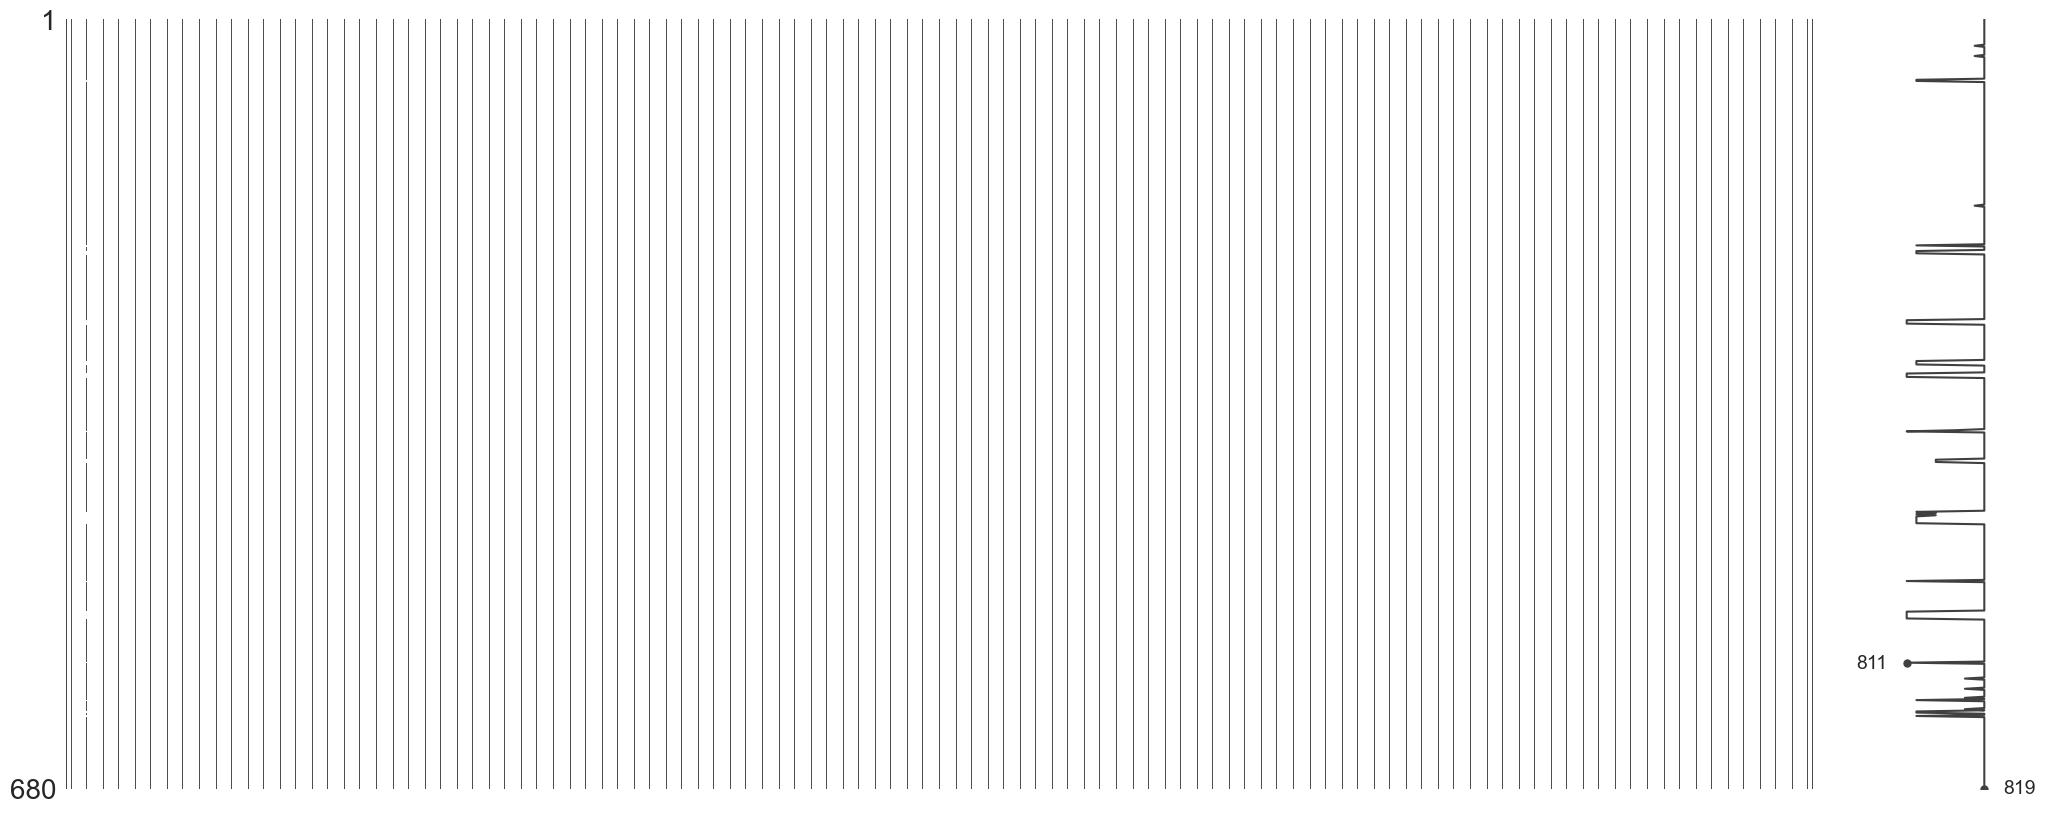

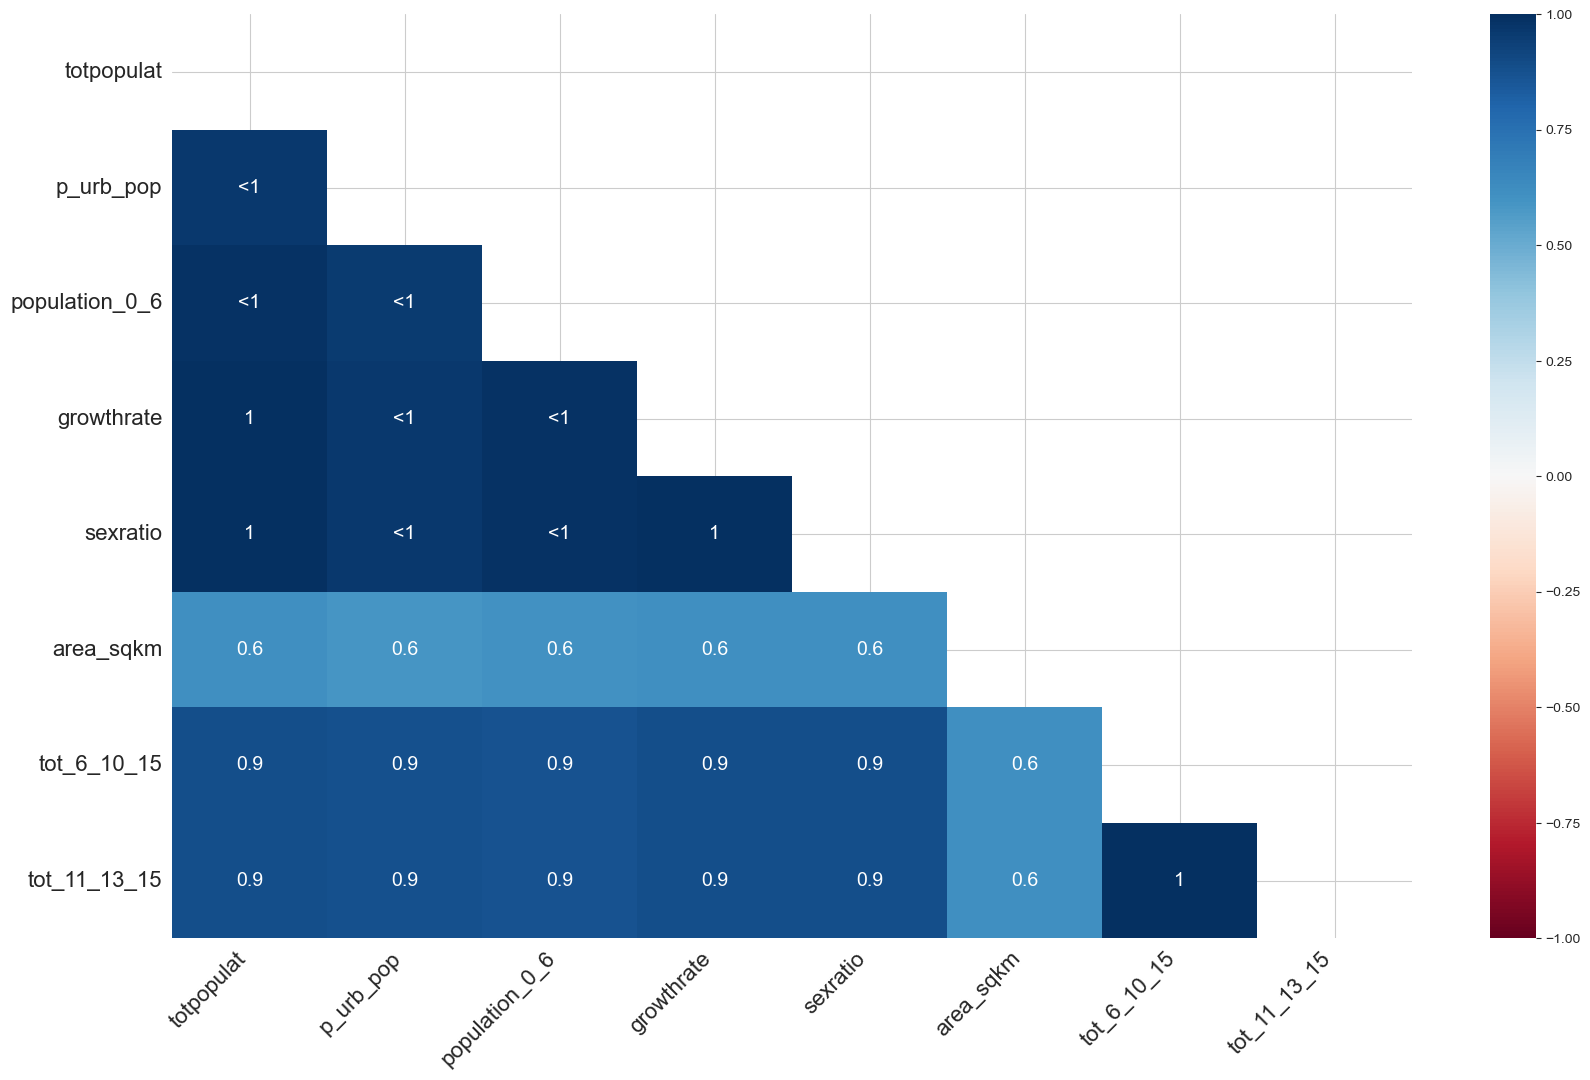

In [73]:
import missingno as msno
import matplotlib.pyplot as plt

# Visualize missingness
msno.matrix(df)
plt.show()

msno.heatmap(df)
plt.show()


# Step 6: outlayer detection and handling :-



 📊 detecting & visualizing outliers:


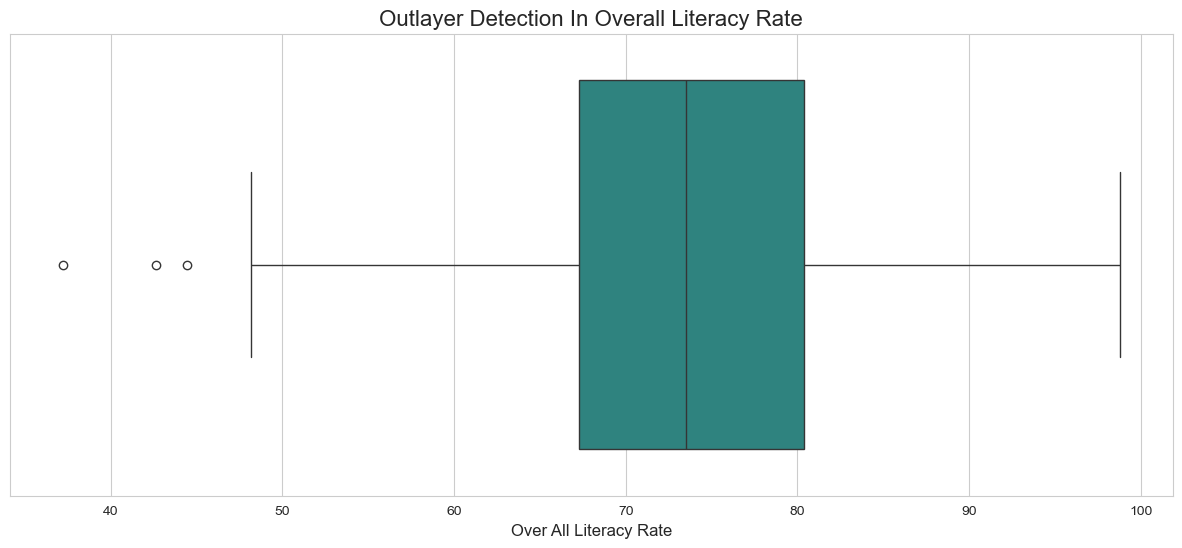

Outliers can be observed in the boxplot. For this analysis, we will retain them as they are likely genuine data points.





In [94]:
print("\n\n 📊 detecting & visualizing outliers:")

# we'll check for outliers in the 'overall_li' column

plt.figure(figsize = (15, 6))
sns.boxplot(x = df_cleaned['overall_li'], palette = 'viridis')
plt.title('Outlayer Detection In Overall Literacy Rate', fontsize = 16)
plt.xlabel('Over All Literacy Rate', fontsize = 12)
plt.show()

# The boxplot may show some districts with unusually low literacy rates. For this
# analysis, we'll keep them as they represent actual data points, but in some
# contexts, one might choose to cap or remove them.
print("Outliers can be observed in the boxplot. For this analysis, we will retain them as they are likely genuine data points.")
print('\n\n')

# Step 7: Advanced data visualization :-



🎨 Generating Advanced Visualization:


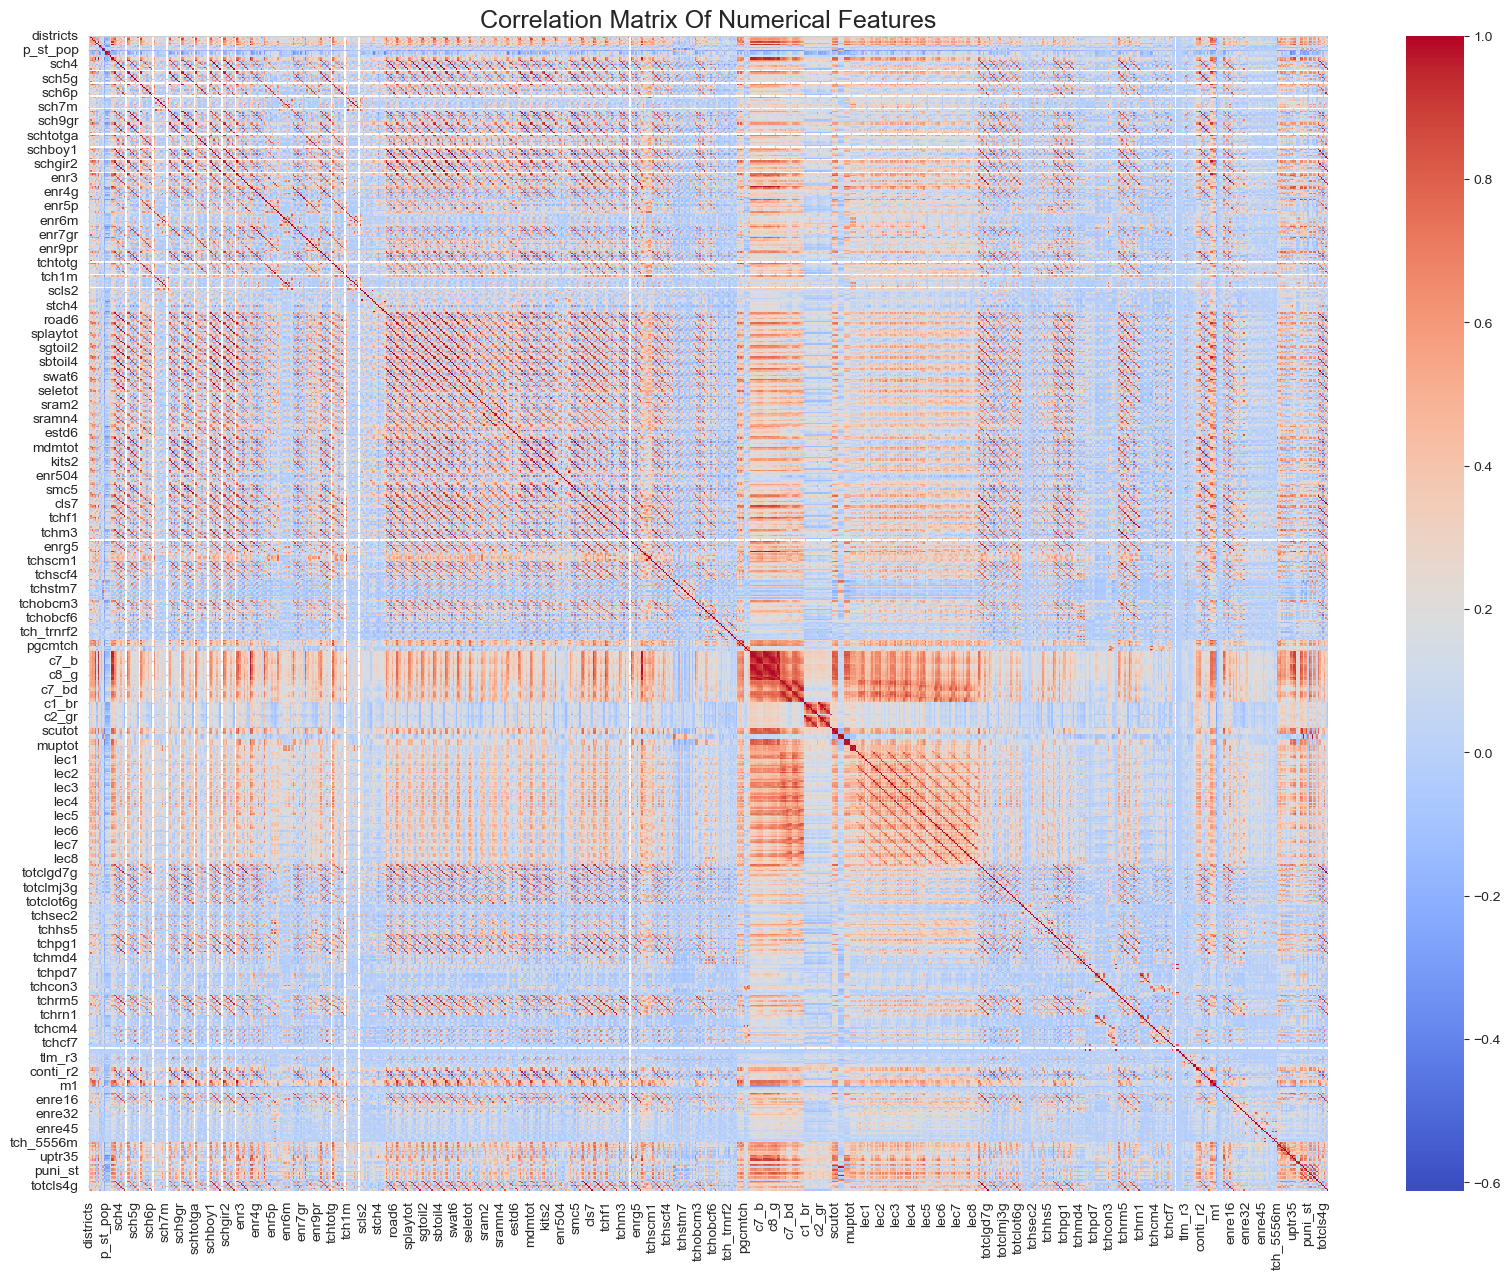


 The correlation heatmap shows the relationships between the variables. for example, literacy rates are highky corrolated with each other.





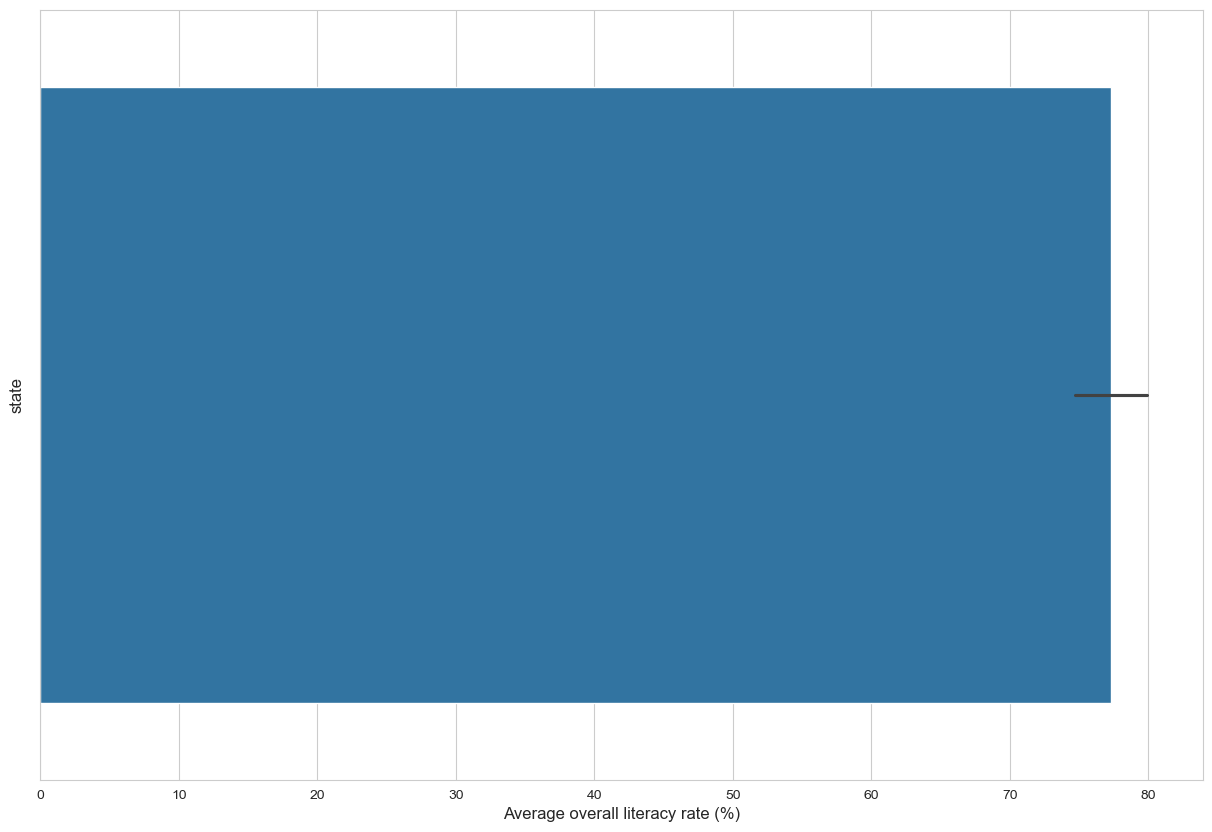


This barchart ranks the states by their averagae literacy rate, providing a clear comparison





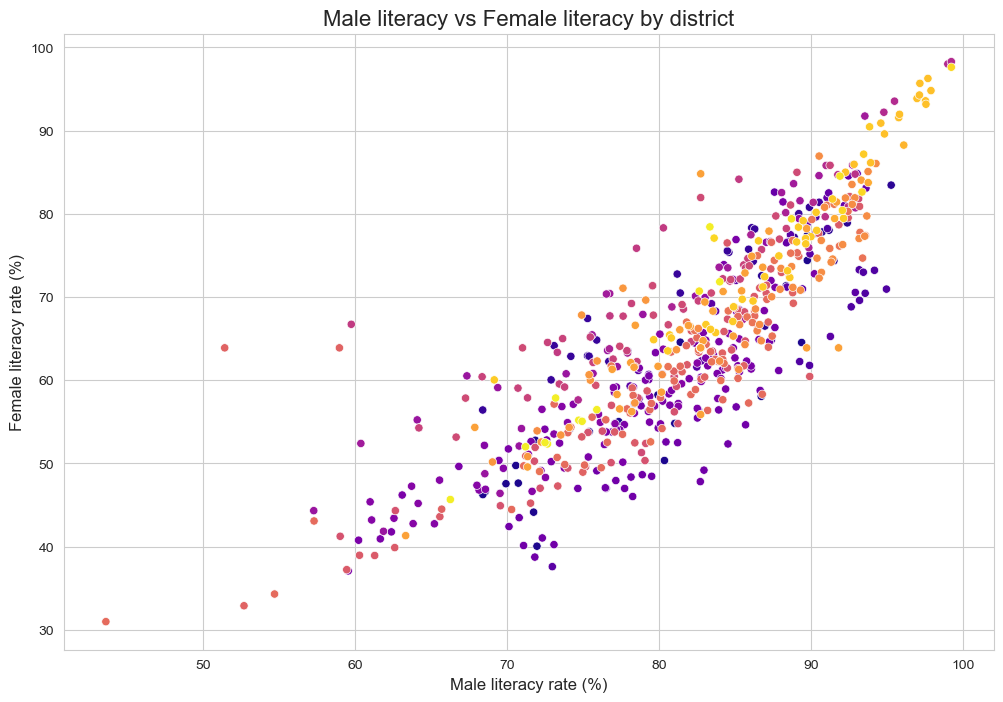


The scatterplot reveals the gender gap in the literacy. Most districts fall below the equiality line, indicating higher male literacy.





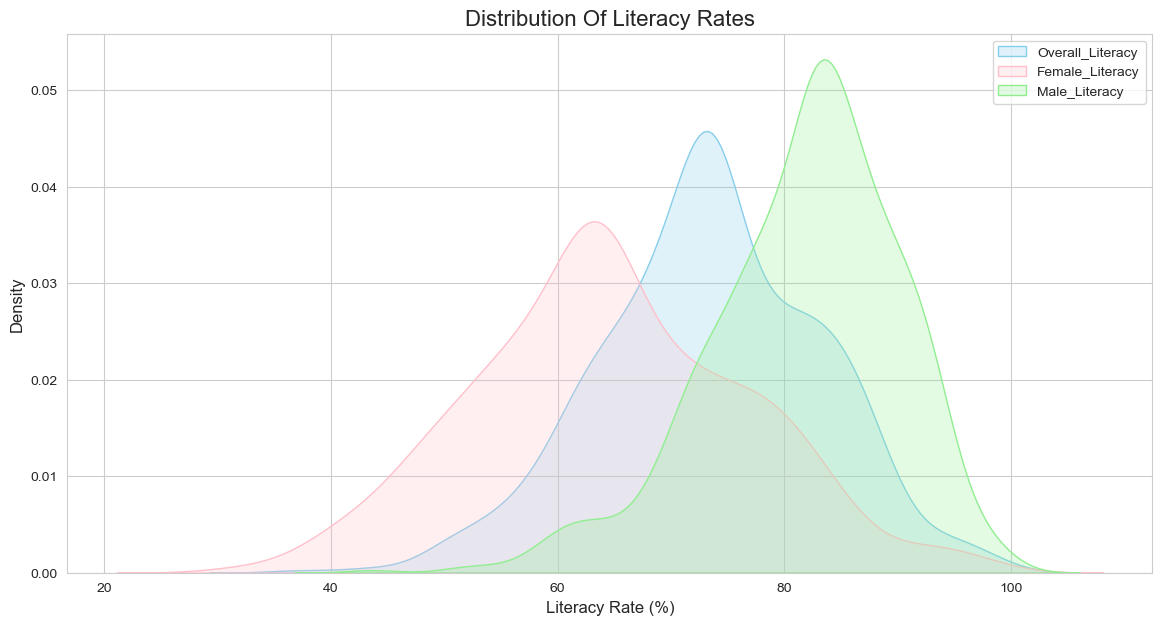


This density plot shows the distribution of literacy rates. highlighting the shift towards lower rates for female literacy comparing to male literacy. 





In [93]:
print('\n\n🎨 Generating Advanced Visualization:')

numeric_cols = df_cleaned.select_dtypes(include = np.number).columns
correlation_matrix = df_cleaned[numeric_cols].corr()

plt.figure(figsize = (20, 15))
sns.heatmap(correlation_matrix, cmap = 'coolwarm', annot = False)
plt.title('Correlation Matrix Of Numerical Features', fontsize = 18)
plt.show()
print('\n The correlation heatmap shows the relationships between the variables. for example, literacy rates are highky corrolated with each other.')
print('\n\n')

#State-wise Literacy Rate Analysis

state_literacy = df_cleaned.groupby('statname')['overall_li'].mean().sort_values(ascending = False)
plt.figure(figsize = (15, 10))
sns.barplot(x= state_literacy.values)
plt.xlabel('Average overall literacy rate (%)', fontsize = 12)
plt.ylabel('state', fontsize = 12)
plt.show()
print('\nThis barchart ranks the states by their averagae literacy rate, providing a clear comparison')
print('\n\n')

# Scatter Plot: Male vs. Female Literacy

plt.figure(figsize = (12, 8))
sns.scatterplot(x = 'male_lit', y = 'female_lit',data = df_cleaned, hue = 'statname', palette = 'plasma', legend = False)
plt.title('Male literacy vs Female literacy by district', fontsize = 16)
plt.xlabel('Male literacy rate (%)', fontsize = 12)
plt.ylabel('Female literacy rate (%)', fontsize = 12)
plt.show()

print('\nThe scatterplot reveals the gender gap in the literacy. Most districts fall below the equiality line, indicating higher male literacy.')
print('\n\n')

# Distribution of literacy rates

plt.figure(figsize = (14,7))
sns.kdeplot(df_cleaned['overall_li'], fill = True, label = 'Overall_Literacy', color = 'skyblue')
sns.kdeplot(df_cleaned['female_lit'], fill = True, label = 'Female_Literacy', color = 'pink')
sns.kdeplot(df_cleaned['male_lit'], fill = True, label = 'Male_Literacy', color = 'lightgreen')
plt.title('Distribution Of Literacy Rates', fontsize = 16)
plt.xlabel('Literacy Rate (%)', fontsize = 12)
plt.ylabel('Density', fontsize = 12)
plt.legend()
plt.show()

print('\nThis density plot shows the distribution of literacy rates. highlighting the shift towards lower rates for female literacy comparing to male literacy. ')
print('\n\n')

# Step 8: Data Splitting and Scaling :-


In [76]:
# Assuming your main DataFrame is named 'df' and it is loaded.
TARGET_COLUMN = 'overall_li'
COLUMNS_TO_DROP_FROM_FEATURES = ['statcd', 'distcd', 'districts'] 

# 1. Select numerical features
df_numeric = df.select_dtypes(include=np.number)

# 2. Define X and Y
X = df_numeric.drop(columns=[TARGET_COLUMN] + COLUMNS_TO_DROP_FROM_FEATURES, errors='ignore')
Y = df_numeric[TARGET_COLUMN]

# 3. Handle any remaining NaN values in features
imputer_X = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer_X.fit_transform(X), columns=X.columns)

print(f"Features (X) Shape: {X.shape}")
print(f"Target (Y) Shape: {Y.shape}")
#split the dat into training and testing sets(70/30 splits)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.3,
    random_state = 42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

# Featuring scaling
# Scaling is necessary for linear and ridge regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


Features (X) Shape: (680, 812)
Target (Y) Shape: (680,)
X_train shape: (476, 812)
X_test shape: (204, 812)


# Model Training And Evaluation :-

In [77]:
#Function to train and evaluate a model

def train_and_evaluate(model, X_train_data, X_test_data, Y_train, Y_test, model_name):
    # Train the model
    model.fit(X_train_data, Y_train)

    # Make prediction
    Y_pred = model.predict(X_test_data)

    # Evaluate the model
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    print(f'---{model_name} Results---')
    print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
    print(f'R-Squared (R2): {r2:.4f}')
    print(f'Mean Absolute Error (MAE):{mae:.2f}')
    print('-' * 35)
    return Y_pred, r2
    



# Step 9: Regressions :-

## Linear Regression (Requires scaled data)

In [78]:
lr_model = LinearRegression()
Y_pred_lr, r2_lr = train_and_evaluate(
    lr_model,
    X_train_scaled, 
    X_test_scaled,
    Y_train,
    Y_test,
    'Linear Regression'

)


---Linear Regression Results---
Root Mean Squared Error (RMSE): 7.45
R-Squared (R2): 0.3990
Mean Absolute Error (MAE):4.78
-----------------------------------


## Ridge Regression (Requires Scaled Data)

In [79]:
ridge = Ridge(alpha = 1.0, random_state = 42)
Y_pred_ridge, r2_ridge = train_and_evaluate(
    ridge,
    X_train_scaled,
    X_test_scaled,
    Y_train,
    Y_test,
    'Ridge Regression'
    
)

---Ridge Regression Results---
Root Mean Squared Error (RMSE): 2.19
R-Squared (R2): 0.9480
Mean Absolute Error (MAE):1.50
-----------------------------------


## Random Forest Regressor (Typically Not Required Scaled Data) 

In [80]:
rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1)
Y_pred_rf,r2_rf = train_and_evaluate(
    rf_model,
    X_train,
    X_test,
    Y_train,
    Y_test,
    'Random Forest Regressor'
    
)

---Random Forest Regressor Results---
Root Mean Squared Error (RMSE): 1.34
R-Squared (R2): 0.9806
Mean Absolute Error (MAE):0.76
-----------------------------------


## visualizing Result :-



✅ Regression analysis completed!


Two plots have been generated: 'Actual Vs. Predicted Literacy.png' and 'Residual Distribution.png'.


A good model will have prediction cluster tightly arround the red line in the scatterplot, And a residual part centered near zero 





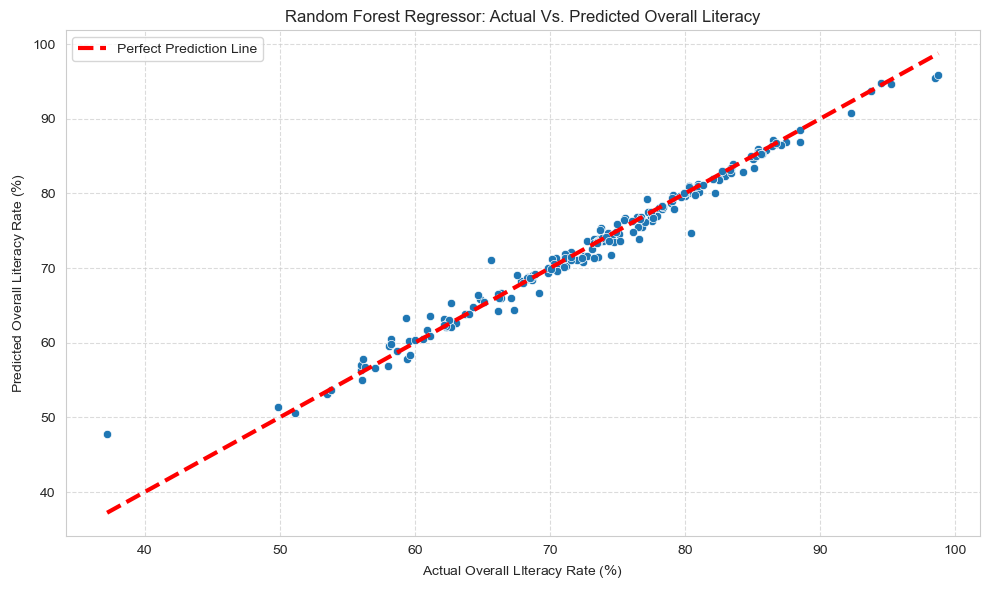

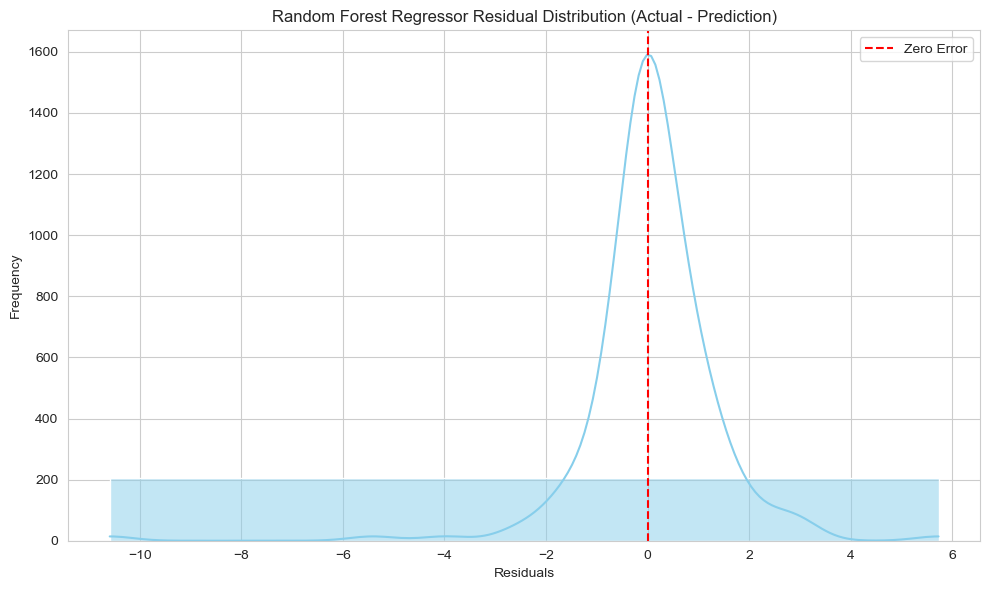

In [96]:
# assuming random forest (RF) as the best model based on R-squared (r2_rf > r2_lr and r2_ridge)

BEST_PREDICTIONS = Y_pred_rf
MODEL_NAME = 'Random Forest Regressor'

#1. Actual vs predicted scatter plot
plt.figure(figsize = (10,6))
sns.scatterplot(x =Y_test, y = BEST_PREDICTIONS)

#add red dashed line representing pefect prediction(y = x)

plt.plot(
    [Y_test.min(),Y_test.max()],
    [Y_test.min(),Y_test.max()],
    'r--',
    lw = 3,
    label = 'Perfect Prediction Line'
)
plt.title(f'{MODEL_NAME}: Actual Vs. Predicted Overall Literacy' )
plt.xlabel('Actual Overall LIteracy Rate ($\%$)')
plt.ylabel('Predicted Overall Literacy Rate ($\%$)')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.savefig('Actual Vs Predicted Literacy.png')  #saved to output for user visibility

#residual Distribution Plot (residuals = actual value - predicted value)
residuals = Y_test - BEST_PREDICTIONS
plt.figure(figsize = (10,6))
sns.histplot(residuals, bins = True, kde = 40, color = 'skyblue' )
plt.title(f'{MODEL_NAME} Residual Distribution (Actual - Prediction)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.axvline(0, color = 'red', linestyle = '--', linewidth = 1.5, label = 'Zero Error')
plt.legend()
plt.tight_layout()
plt.savefig('Residual Distribution.png')    #saved to output for user visibility

print(f'\n\n✅ Regression analysis completed!')
print('\n')
print("Two plots have been generated: 'Actual Vs. Predicted Literacy.png' and 'Residual Distribution.png'.")
print('\n')
print('A good model will have prediction cluster tightly arround the red line in the scatterplot, And a residual part centered near zero ')
print('\n\n')